# Random Forest & XGBoost Models
**Renewable Energy Production Prediction — Advanced Modeling**

This notebook trains and evaluates Random Forest and XGBoost regressors on the cleaned, weather-enriched dataset, following the same feature preparation approach as the Linear Regression baseline (for a fair comparison).

## 1. Load the Cleaned Dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

df = pd.read_csv("../Data/Cleaned/Cleaned_Production_Data.csv")
print(f"Dataset loaded: {len(df):,} rows, {len(df.columns)} columns")
df.head()

Dataset loaded: 51,862 rows, 31 columns


,Date,Start_Hour,End_Hour,Day_of_Year,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Source_Wind,...,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes
0,2025-11-30,21,22,334,5281,11.8,72,0.0,5.9,1,...,0,0,0,0,0,0,1,0,0,0
1,2025-11-30,18,19,334,3824,13.5,67,0.0,7.2,1,...,0,0,0,0,0,0,1,0,0,0
2,2025-11-30,16,17,334,3824,17.3,50,0.0,5.1,1,...,0,0,0,0,0,0,1,0,0,0
3,2025-11-30,23,0,334,6120,10.4,69,0.0,5.4,1,...,0,0,0,0,0,0,1,0,0,0
4,2025-11-30,6,7,334,4387,8.2,62,0.0,1.6,1,...,0,0,0,0,0,0,1,0,0,0


## 2. Feature Preparation

Same approach as the baseline model: extract `Year` from `Date`, then drop `Date` (raw dates aren't usable by models and would cause overfitting to specific calendar dates rather than general patterns).

In [11]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

df_model = df.drop(columns=["Date"])

print("Features available:", df_model.columns.tolist())

Features available: ['Start_Hour', 'End_Hour', 'Day_of_Year', 'Production', 'Temperature_C', 'Humidity_Percent', 'Precipitation_mm', 'WindSpeed_kmh', 'Source_Wind', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day_Name_Monday', 'Day_Name_Saturday', 'Day_Name_Sunday', 'Day_Name_Thursday', 'Day_Name_Tuesday', 'Day_Name_Wednesday', 'Month_Name_August', 'Month_Name_December', 'Month_Name_February', 'Month_Name_January', 'Month_Name_July', 'Month_Name_June', 'Month_Name_March', 'Month_Name_May', 'Month_Name_November', 'Month_Name_October', 'Month_Name_September', 'Rainfall_Flag_Yes', 'Year']


**Note on Start_Hour / End_Hour:** our multicollinearity check in the baseline model found a correlation of 0.76 between these two features — moderately related, but below our 0.9 threshold for dropping. Both are retained here for consistency with the baseline model.

## 3. Split Features and Target

In [12]:
X = df_model.drop(columns=["Production"])
y = df_model["Production"]

print("Features used:", X.columns.tolist())

Features used: ['Start_Hour', 'End_Hour', 'Day_of_Year', 'Temperature_C', 'Humidity_Percent', 'Precipitation_mm', 'WindSpeed_kmh', 'Source_Wind', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day_Name_Monday', 'Day_Name_Saturday', 'Day_Name_Sunday', 'Day_Name_Thursday', 'Day_Name_Tuesday', 'Day_Name_Wednesday', 'Month_Name_August', 'Month_Name_December', 'Month_Name_February', 'Month_Name_January', 'Month_Name_July', 'Month_Name_June', 'Month_Name_March', 'Month_Name_May', 'Month_Name_November', 'Month_Name_October', 'Month_Name_September', 'Rainfall_Flag_Yes', 'Year']


## 4. Train/Test Split

Using the same split parameters as the baseline model (`test_size=0.2`, `random_state=42`) so all models are compared on identical data.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (41489, 30)
Testing set: (10373, 30)


**Note on feature scaling:** unlike Linear Regression, tree-based models (Random Forest, XGBoost) split on feature thresholds rather than computing weighted sums — so they don't require scaled/standardized features. No scaling is applied here.

## 5. Random Forest Regressor

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"  RMSE: {rmse_rf:.2f} MWh")
print(f"  MAE:  {mae_rf:.2f} MWh")
print(f"  R2:   {r2_rf:.4f}")

Random Forest Performance:
  RMSE: 1930.28 MWh
  MAE:  1315.89 MWh
  R2:   0.7634


### Random Forest: Actual vs Predicted & Residuals

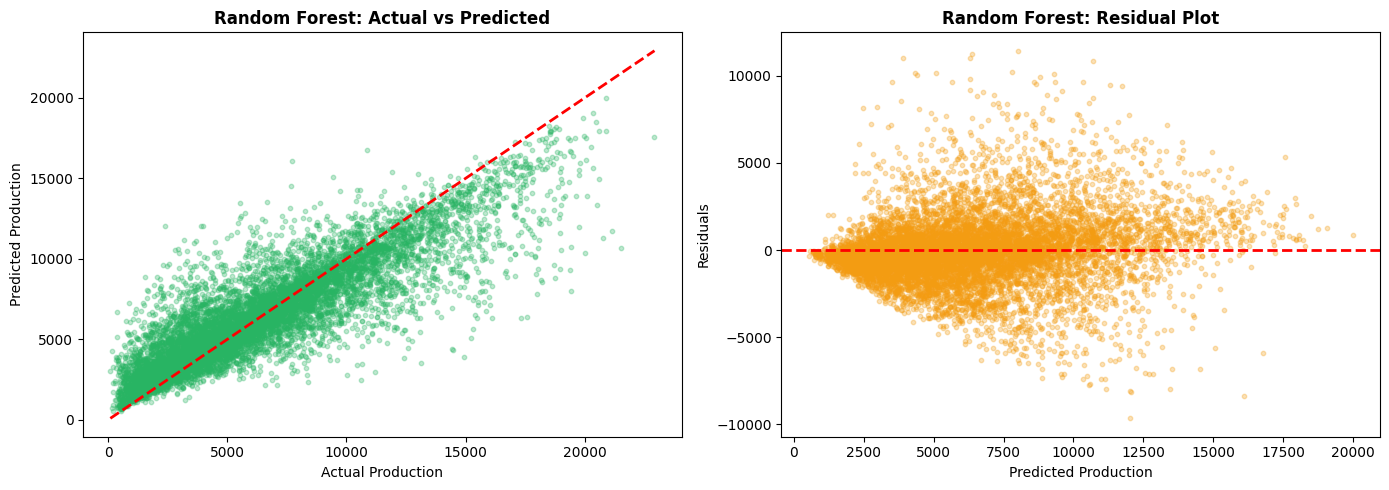

In [15]:
os.makedirs('../Visualisations/Models', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.3, color='#28B463', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('Actual Production')
axes[0].set_ylabel('Predicted Production')
axes[0].set_title('Random Forest: Actual vs Predicted', fontweight='bold')

residuals_rf = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.3, color='#F39C12', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Production')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Random Forest: Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('../Visualisations/Models/random_forest_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. XGBoost Regressor

In [16]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print(f"  RMSE: {rmse_xgb:.2f} MWh")
print(f"  MAE:  {mae_xgb:.2f} MWh")
print(f"  R2:   {r2_xgb:.4f}")

XGBoost Performance:
  RMSE: 2516.84 MWh
  MAE:  1943.51 MWh
  R2:   0.5978


### XGBoost: Actual vs Predicted & Residuals

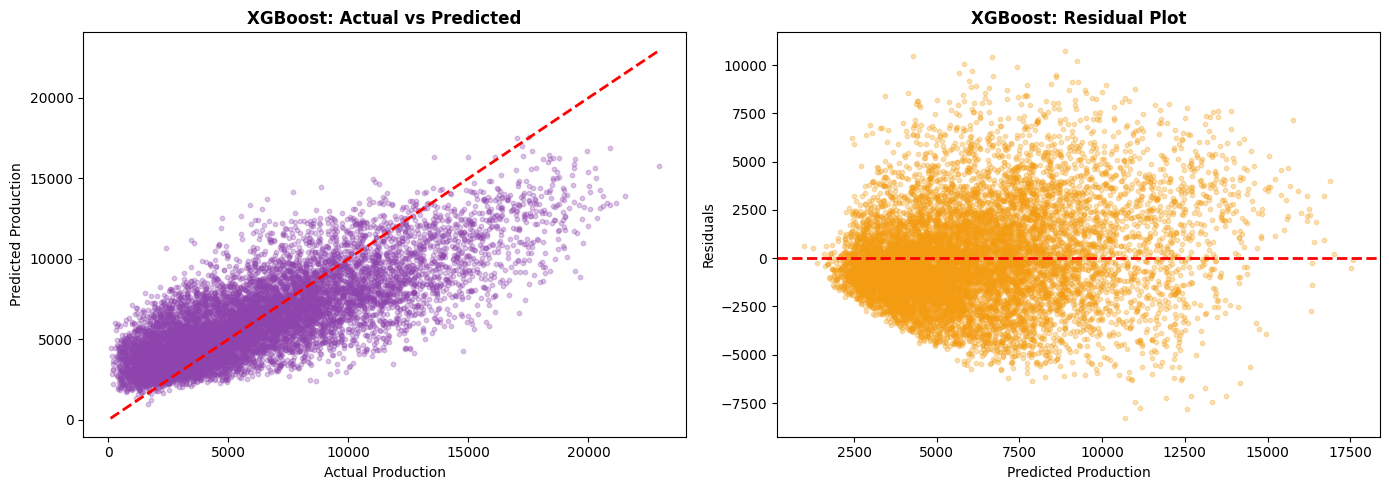

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_xgb, alpha=0.3, color='#8E44AD', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('Actual Production')
axes[0].set_ylabel('Predicted Production')
axes[0].set_title('XGBoost: Actual vs Predicted', fontweight='bold')

residuals_xgb = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.3, color='#F39C12', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Production')
axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost: Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('../Visualisations/Models/xgboost_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

**Note:** these are initial results using standard, reasonable parameters (not deeply tuned). We're checking in on this stage before investing time in full hyperparameter tuning (e.g. GridSearchCV/RandomizedSearchCV), in case the modeling approach or features change based on feedback.

## Save Trained Models and Results

In [18]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rmse_rf, rmse_xgb],
    "MAE": [mae_rf, mae_xgb],
    "R2": [r2_rf, r2_xgb]
})

results.to_csv("../Data/ModelResults/advanced_model_results.csv", index=False)

print("Saved: advanced_model_results.csv")
print()
print(results.to_string(index=False))

Saved: advanced_model_results.csv

        Model        RMSE         MAE       R2
Random Forest 1930.280432 1315.889359 0.763430
      XGBoost 2516.837301 1943.512573 0.597812


## Summary

- Trained Random Forest and XGBoost on the same features and train/test split as the Linear Regression baseline
- Results saved to `advanced_model_results.csv`